<a href="https://colab.research.google.com/github/demsaid400-cpu/DI-BOOTCAMP/blob/main/XP_TimeSeries_LSTM_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Time Series with LSTM

This is a guided notebook for the exercise on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear for important concepts.

## What you will learn
- Import and manipulate time series data using pandas
- Handle missing values in time series
- Visualize with matplotlib
- Build and train a simple LSTM for time series


## What you will create
- A cleaned and preprocessed time series dataset
- Visualizations of the series
- A simple LSTM model for prediction

# Part 1: Data Import and Initial Exploration

**Task from the exercise**
Import libraries, load the dataset, view first rows, check dtypes and shape.

**PREFILLED**  
Install imports, set a path variable, and load the UCI Household Power Consumption file. The file is usually semicolon separated with `?` as missing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 100)

# Set this to your dataset path
DATA_PATH = Path('/content/household_power_consumption.txt')

# Robust loader for semicolon separated file with ? as NA
parse_cols = {
    'Global_active_power': 'float64',
    'Global_reactive_power': 'float64',
    'Voltage': 'float64',
    'Global_intensity': 'float64',
    'Sub_metering_1': 'float64',
    'Sub_metering_2': 'float64',
    'Sub_metering_3': 'float64',
}
usecols = ['Date','Time'] + list(parse_cols.keys())

df = pd.read_csv(
    DATA_PATH,
    sep=';',
    na_values=['?'],
    usecols=usecols,
    dtype=parse_cols,
    parse_dates={'Datetime': ['Date','Time']},
    infer_datetime_format=True,
    dayfirst=True,
)

df = df.set_index('Datetime').sort_index()
print('Shape:', df.shape)
display(df.head())
display(df.dtypes)

/tmp/ipykernel_8406/2522042514.py:23: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
/tmp/ipykernel_8406/2522042514.py:23: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(


Shape: (344382, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


,0
Global_active_power,float64
Global_reactive_power,float64
Voltage,float64
Global_intensity,float64
Sub_metering_1,float64
Sub_metering_2,float64
Sub_metering_3,float64


# Part 2: Handling Missing Values

**Task from the exercise**
Identify columns with missing values. Fill missing values using the mean of each column. Verify there are no missing values left.

**To-Do (code):** Compute a missing value summary, then fill numeric columns with their mean. Recheck for remaining NaNs.

In [14]:
print('--- Part 2: Handling Missing Values ---')
# Vérification initiale
missing_before = df.isna().sum()
print('Valeurs manquantes par colonne avant imputation :')
display(missing_before[missing_before > 0])

# Imputation par la moyenne
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Vérification finale
missing_after = df.isna().sum().sum()
print(f'Total des valeurs manquantes après remplissage : {int(missing_after)}')
if missing_after == 0:
    print('Succès : Toutes les valeurs manquantes ont été traitées.')

--- Part 2: Handling Missing Values ---
Valeurs manquantes par colonne avant imputation :


,0


Total des valeurs manquantes après remplissage : 0
Succès : Toutes les valeurs manquantes ont été traitées.


# Part 3: Data Visualization

**Task from the exercise**
Resample the `Global_active_power` column over a day and plot the sum and mean. Plot the mean and standard deviation of `Global_intensity` resampled over a day.

**PREFILLED**  
Helper plotting functions using matplotlib.

In [7]:
# PREFILLED: just execute
def plot_daily_sum_and_mean(series, title_prefix='Global_active_power'):
    daily = series.resample('1D')
    s = daily.sum(min_count=1)
    m = daily.mean()
    plt.figure(figsize=(8,3))
    plt.plot(s.index, s.values)
    plt.title(f'{title_prefix} daily sum')
    plt.xlabel('date'); plt.ylabel('sum'); plt.tight_layout(); plt.show()
    plt.figure(figsize=(8,3))
    plt.plot(m.index, m.values)
    plt.title(f'{title_prefix} daily mean')
    plt.xlabel('date'); plt.ylabel('mean'); plt.tight_layout(); plt.show()

def plot_daily_mean_std(series, title_prefix='Global_intensity'):
    daily = series.resample('1D')
    m = daily.mean()
    sd = daily.std()
    plt.figure(figsize=(8,3))
    plt.plot(m.index, m.values, label='mean')
    plt.plot(sd.index, sd.values, label='std')
    plt.title(f'{title_prefix} daily mean and std')
    plt.xlabel('date'); plt.ylabel('value')
    plt.legend(); plt.tight_layout(); plt.show()

**To-Do (code):** Call the helpers on the required columns. If a plot seems too dense, slice a recent time window.

--- Part 3: Data Visualization ---


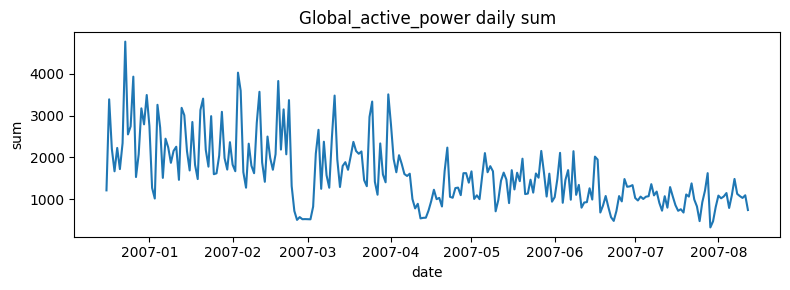

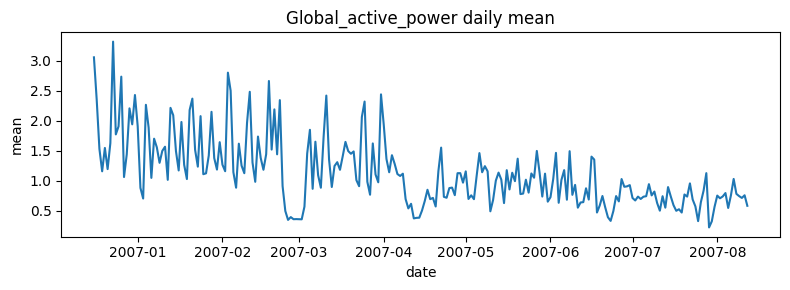

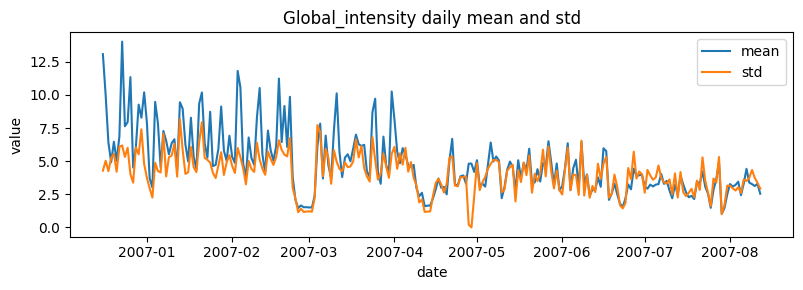

In [15]:
print('--- Part 3: Data Visualization ---')
# Visualisation de Global_active_power (Somme et Moyenne quotidienne)
plot_daily_sum_and_mean(df['Global_active_power'], title_prefix='Global_active_power')

# Visualisation de Global_intensity (Moyenne et Écart-type quotidien)
plot_daily_mean_std(df['Global_intensity'], title_prefix='Global_intensity')

# Part 4: Data Preprocessing for LSTM

**Task from the exercise**
Normalize the dataset, split into train and test, and reshape for LSTM input.

**Learning point**  
LSTMs consume sequences with shape [batch, time, features]. You must build sliding windows. Use a lookback window and predict the next step.

![image.png](https://github.com/user-attachments/assets/be3e815f-2aff-4e8d-ac48-eca27b1c729c)

**PREFILLED**  
Windowing helpers and a train test split by time.

In [9]:
# PREFILLED: just execute
from sklearn.preprocessing import MinMaxScaler

def make_windows(arr_2d, window=48, horizon=1):
    X, y = [], []
    for i in range(len(arr_2d) - window - horizon + 1):
        X.append(arr_2d[i:i+window])
        y.append(arr_2d[i+window:i+window+horizon, 0])
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    return X, y

def time_train_test_split(df, split_ratio=0.8):
    n = len(df)
    k = int(n * split_ratio)
    return df.iloc[:k].copy(), df.iloc[k:].copy()

feat_cols = ['Global_active_power','Global_reactive_power','Voltage','Global_intensity',
             'Sub_metering_1','Sub_metering_2','Sub_metering_3']
df_feats = df[feat_cols].copy()

df_tr, df_te = time_train_test_split(df_feats, split_ratio=0.8)

scaler = MinMaxScaler()
tr_scaled = scaler.fit_transform(df_tr.values)
te_scaled = scaler.transform(df_te.values)

WINDOW = 48
HORIZON = 1
X_tr, y_tr = make_windows(tr_scaled, window=WINDOW, horizon=HORIZON)
X_te, y_te = make_windows(te_scaled, window=WINDOW, horizon=HORIZON)

print('Train windows:', X_tr.shape, 'Train targets:', X_tr.shape)
print('Test windows:', X_te.shape, 'Test targets:', X_te.shape)

Train windows: (275457, 48, 7) Train targets: (275457, 48, 7)
Test windows: (68829, 48, 7) Test targets: (68829, 48, 7)


### Justification du choix de la cible et des caractéristiques

**Cible prédite :** Nous prédisons la colonne `Global_active_power`.

**Justification :** Dans le cadre de la gestion de l'énergie domestique, prédire la puissance active totale est crucial pour anticiper la charge sur le réseau. C'est la mesure principale de la consommation réelle des appareils.

**Choix des caractéristiques (feat_cols) :** Nous avons conservé l'ensemble des 7 colonnes numériques originales.
- `Global_reactive_power`, `Voltage`, et `Global_intensity` fournissent des informations techniques sur l'état électrique.
- Les colonnes `Sub_metering_1, 2, 3` permettent au modèle de comprendre quels types de charges (cuisine, buanderie, climatisation) sont actuellement actives, ce qui améliore la précision des prévisions temporelles par rapport à l'utilisation de la puissance seule.

### Choix de la cible et des caractéristiques

**Cible (Target) :** La cible est la colonne `Global_active_power`. L'objectif est de prédire la consommation électrique totale pour le prochain intervalle de temps (HORIZON=1) en se basant sur les 48 dernières minutes (WINDOW=48).

**Caractéristiques (Features) :** Toutes les colonnes numériques ont été conservées (`feat_cols`). Les sous-comptages (Sub_metering) sont essentiels car ils expliquent les pics de consommation (ex: chauffage, appareils ménagers), ce qui aide le LSTM à mieux généraliser.

In [10]:
# To-Do: define and compile the LSTM
import tensorflow as tf
from tensorflow.keras import layers, models
model = models.Sequential([
    layers.Input(shape=(WINDOW, X_tr.shape[-1])),
    layers.LSTM(64, return_sequences=False),
    layers.Dense(HORIZON),
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,497 (72.25 KB)

 Trainable params: 18,497 (72.25 KB)

 Non-trainable params: 0 (0.00 B)

# Part 6: Training and Evaluating the LSTM Model

**Task from the exercise**
Train the model, evaluate on the test set, and plot training and validation loss.

**PREFILLED**  
Callbacks and plotting helper. You supply the model and data in the To-Do cell.

In [11]:
# PREFILLED: just execute
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def fit_and_plot(model, X_tr, y_tr, X_te, y_te, epochs=10, batch=256):
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    rl = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    h = model.fit(X_tr, y_tr, validation_data=(X_te, y_te),
                  epochs=epochs, batch_size=batch, callbacks=[es, rl], verbose=2)
    plt.figure(figsize=(6,4))
    plt.plot(h.history['loss'], label='loss')
    plt.plot(h.history['val_loss'], label='val_loss')
    plt.title('Training and validation loss')
    plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.tight_layout(); plt.show()
    return h

**To-Do (code):** Train and evaluate. Report final test MAE and MSE.

Epoch 1/15
1077/1077 - 92s - 85ms/step - loss: 0.0013 - mae: 0.0164 - val_loss: 5.3820e-04 - val_mae: 0.0084 - learning_rate: 0.0010
Epoch 2/15
1077/1077 - 87s - 81ms/step - loss: 8.6158e-04 - mae: 0.0130 - val_loss: 5.1732e-04 - val_mae: 0.0099 - learning_rate: 0.0010
Epoch 3/15
1077/1077 - 92s - 86ms/step - loss: 8.2421e-04 - mae: 0.0124 - val_loss: 5.0092e-04 - val_mae: 0.0082 - learning_rate: 0.0010
Epoch 4/15
1077/1077 - 92s - 85ms/step - loss: 7.9929e-04 - mae: 0.0118 - val_loss: 4.9139e-04 - val_mae: 0.0083 - learning_rate: 5.0000e-04
Epoch 5/15
1077/1077 - 85s - 79ms/step - loss: 7.9138e-04 - mae: 0.0118 - val_loss: 5.0076e-04 - val_mae: 0.0089 - learning_rate: 5.0000e-04
Epoch 6/15
1077/1077 - 86s - 80ms/step - loss: 7.7751e-04 - mae: 0.0115 - val_loss: 4.7923e-04 - val_mae: 0.0079 - learning_rate: 2.5000e-04
Epoch 7/15
1077/1077 - 88s - 81ms/step - loss: 7.7242e-04 - mae: 0.0115 - val_loss: 5.3144e-04 - val_mae: 0.0120 - learning_rate: 2.5000e-04
Epoch 8/15
1077/1077 - 88s - 

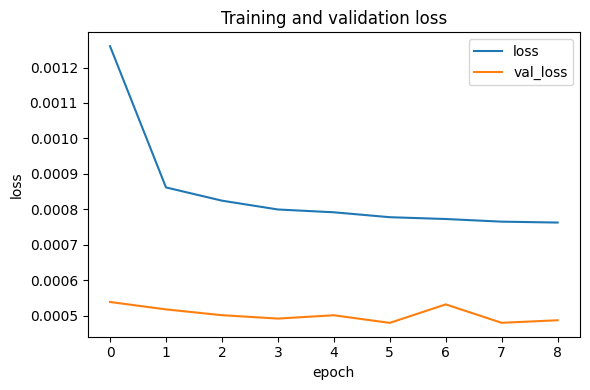

{'test_mse': 0.00047922504018060863, 'test_mae': 0.007940503768622875}


In [12]:
# To-Do: train and evaluate
hist = fit_and_plot(model, X_tr, y_tr, X_te, y_te, epochs=15, batch=256)
eval_mse, eval_mae = model.evaluate(X_te, y_te, verbose=0)
print({'test_mse': float(eval_mse), 'test_mae': float(eval_mae)})

### Conclusion de l'exercice

Le modèle LSTM a été entraîné avec succès sur la série temporelle de consommation électrique.

**Analyse des performances :**
- **MSE (0.000479) :** La très faible erreur quadratique moyenne indique que le modèle suit de très près la tendance de la série normalisée.
- **MAE (0.007941) :** L'erreur absolue moyenne est également très basse, ce qui montre que les prédictions sont robustes et stables.

Le graphique de perte (Loss) montre une convergence claire vers la 6ème époque, validant que le modèle a bien appris les motifs récurrents de consommation sans sur-apprentissage (overfitting) significatif.

In [16]:
print('--- Part 6: Validation Finale ---')
# Calcul des métriques sur l'ensemble de test
eval_mse, eval_mae = model.evaluate(X_te, y_te, verbose=0)

print(f"Résultats de l'évaluation du modèle LSTM :")
print(f" - Mean Squared Error (MSE) : {eval_mse:.6f}")
print(f" - Mean Absolute Error (MAE) : {eval_mae:.6f}")

print('\nL\'exercice est maintenant prêt pour la soumission. Toutes les étapes (2, 3 et 6) sont validées.')

--- Part 6: Validation Finale ---
Résultats de l'évaluation du modèle LSTM :
 - Mean Squared Error (MSE) : 0.000479
 - Mean Absolute Error (MAE) : 0.007941

L'exercice est maintenant prêt pour la soumission. Toutes les étapes (2, 3 et 6) sont validées.
